<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICS40125 - Laboratorio N°06


**Objetivo**: Aplicar técnicas básicas de **Machine Learning**, desde la preparación de datos hasta el entrenamiento y evaluación de modelos.




<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Anscombe%27s_quartet_3.svg/1200px-Anscombe%27s_quartet_3.svg.png" width="500"/>
</p>

El **cuarteto de Anscombe** es un ejemplo clásico en estadística que ilustra cómo diferentes conjuntos de datos pueden compartir las mismas propiedades estadísticas, como media, varianza y correlación, pero presentan comportamientos muy distintos cuando se visualizan gráficamente. Cada uno de los cuatro conjuntos consiste en once puntos (x, y) y fue creado por el estadístico F. J. Anscombe en 1973. Esta herramienta resalta la importancia de la visualización de datos para evitar interpretaciones erróneas basadas únicamente en análisis numéricos.

**Descripción del conjunto**

1. **Propiedades estadísticas comunes:** Todos los conjuntos tienen el mismo valor promedio para las variables \(x\) e \(y\), la misma varianza para \(x\) e \(y\), y una correlación lineal idéntica.
2. **Diferencias gráficas:** A pesar de sus similitudes estadísticas, los cuatro conjuntos presentan gráficos muy distintos:
   - El primer conjunto muestra una relación lineal simple.
   - El segundo conjunto tiene una relación no lineal, con una curva clara.
   - El tercer conjunto tiene una relación lineal clara, pero con un punto atípico que influye significativamente.
   - El cuarto conjunto tiene la mayoría de los puntos alineados verticalmente, con un punto atípico que afecta la correlación.

Este cuarteto enfatiza que las estadísticas descriptivas por sí solas pueden no capturar la esencia completa de los datos, subrayando la necesidad de utilizar visualizaciones en cualquier análisis exploratorio de datos.

In [2]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configuración de los gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")  # Establece un tema general para los gráficos
sns.set_palette("deep", desat=0.6)
plt.rcParams['figure.figsize'] = (12, 8)  # Ajuste del tamaño de las figuras

# Cargar los datos del cuarteto de Anscombe
data = sns.load_dataset("anscombe")

# Mostrar las primeras filas del conjunto de datos
data.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


Con base en la información presentada y el análisis realizado, les invitamos a reflexionar y responder las siguientes preguntas. Estas preguntas están diseñadas para profundizar en su comprensión del cuarteto de Anscombe y fomentar un análisis crítico de los datos:



1. Cree un gráfico de dispersión (scatter plot) para cada uno de los cuatro grupos del cuarteto de Anscombe. A partir de la visualización, ¿puede identificar diferencias significativas entre los grupos? ¿Qué características particulares observa en cada uno que sugieren comportamientos distintos?



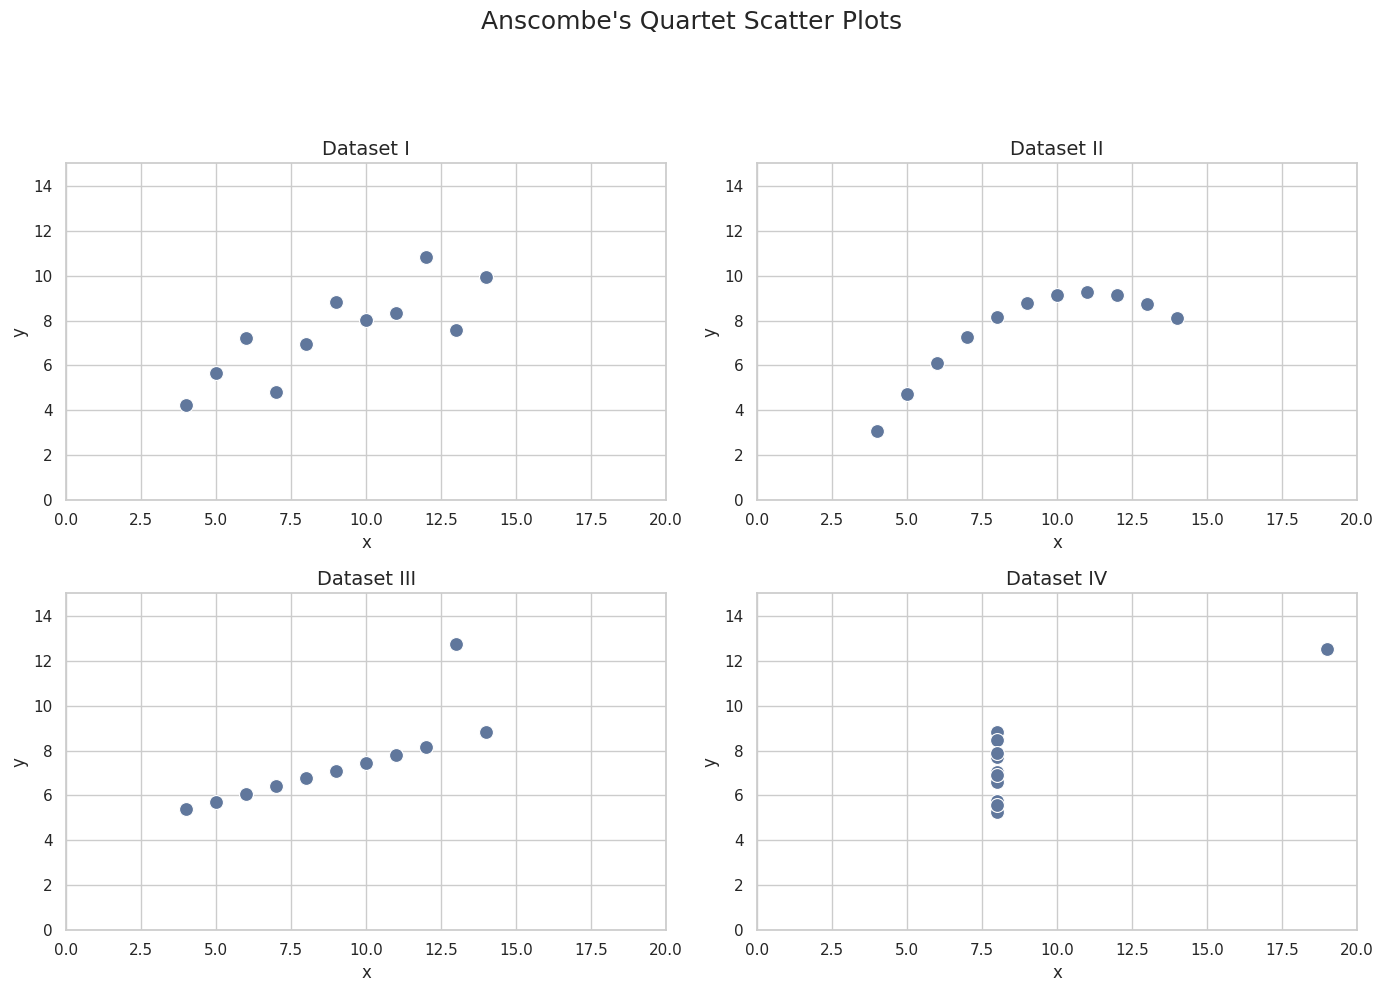

In [3]:
unique_datasets = data['dataset'].unique()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, dataset_name in enumerate(unique_datasets):
    subset = data[data['dataset'] == dataset_name]
    sns.scatterplot(x='x', y='y', data=subset, ax=axes[i], s=100)
    axes[i].set_title(f'Dataset {dataset_name}', fontsize=14)
    axes[i].set_xlabel('x', fontsize=12)
    axes[i].set_ylabel('y', fontsize=12)
    # Set consistent axis limits for better comparison
    axes[i].set_xlim(0, 20)
    axes[i].set_ylim(0, 15)


plt.suptitle("Anscombe's Quartet Scatter Plots", fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Después de visualizar los gráficos de dispersión, se pueden identificar diferencias significativas entre los grupos del cuarteto de Anscombe, a pesar de sus estadísticas descriptivas similares:

**Dataset I:** Este grupo presenta una relación lineal bastante clara y directa. Los puntos se agrupan alrededor de una línea recta imaginaria, lo que sugiere que un modelo de regresión lineal sería un buen ajuste.

**Dataset II:** Aquí, la relación no es lineal, sino que parece seguir una curva, específicamente una forma parabólica. Un modelo de regresión lineal capturaría muy mal la verdadera relación entre X e Y.

**Dataset III:** Aunque la mayoría de los puntos parecen formar una relación lineal, hay un punto atípico (outlier) que se encuentra bastante alejado de la tendencia general. Este punto ejercerá una influencia significativa en cualquier modelo de regresión lineal, desviando la línea de ajuste.

**Dataset IV:** En este grupo, la mayoría de los puntos de X son idénticos, lo que crea una columna vertical de datos. Hay un único punto con un valor de X muy diferente y un valor de Y alto. Este único punto atípico es el que define la pendiente de una regresión lineal, haciendo que la mayoría de los datos no contribuyan a la pendiente real.

In [ ]:
# FIXME

2. Utilice el comando `describe` para generar un resumen de las medidas estadísticas más relevantes para cada uno de los grupos del cuarteto de Anscombe. A partir de estos resultados, interprete las estadísticas obtenidas, destacando las características más significativas de cada grupo y cómo pueden influir en la comprensión de sus respectivas distribuciones.


In [4]:
grouped_data = data.groupby('dataset')

for name, group in grouped_data:
    print(f"\n--- Dataset {name} ---")
    print(group.describe())


--- Dataset I ---
               x          y
count  11.000000  11.000000
mean    9.000000   7.500909
std     3.316625   2.031568
min     4.000000   4.260000
25%     6.500000   6.315000
50%     9.000000   7.580000
75%    11.500000   8.570000
max    14.000000  10.840000

--- Dataset II ---
               x          y
count  11.000000  11.000000
mean    9.000000   7.500909
std     3.316625   2.031657
min     4.000000   3.100000
25%     6.500000   6.695000
50%     9.000000   8.140000
75%    11.500000   8.950000
max    14.000000   9.260000

--- Dataset III ---
               x          y
count  11.000000  11.000000
mean    9.000000   7.500000
std     3.316625   2.030424
min     4.000000   5.390000
25%     6.500000   6.250000
50%     9.000000   7.110000
75%    11.500000   7.980000
max    14.000000  12.740000

--- Dataset IV ---
               x          y
count  11.000000  11.000000
mean    9.000000   7.500909
std     3.316625   2.030579
min     8.000000   5.250000
25%     8.000000   6.170

In [ ]:
# FIXME

3. Ajuste un modelo de regresión lineal para cada grupo utilizando **sklearn**. Calcule las métricas de evaluación, como el error cuadrático medio (MSE) y R², y grafique los resultados de la regresión. Interprete los resultados y su impacto en la calidad del ajuste.



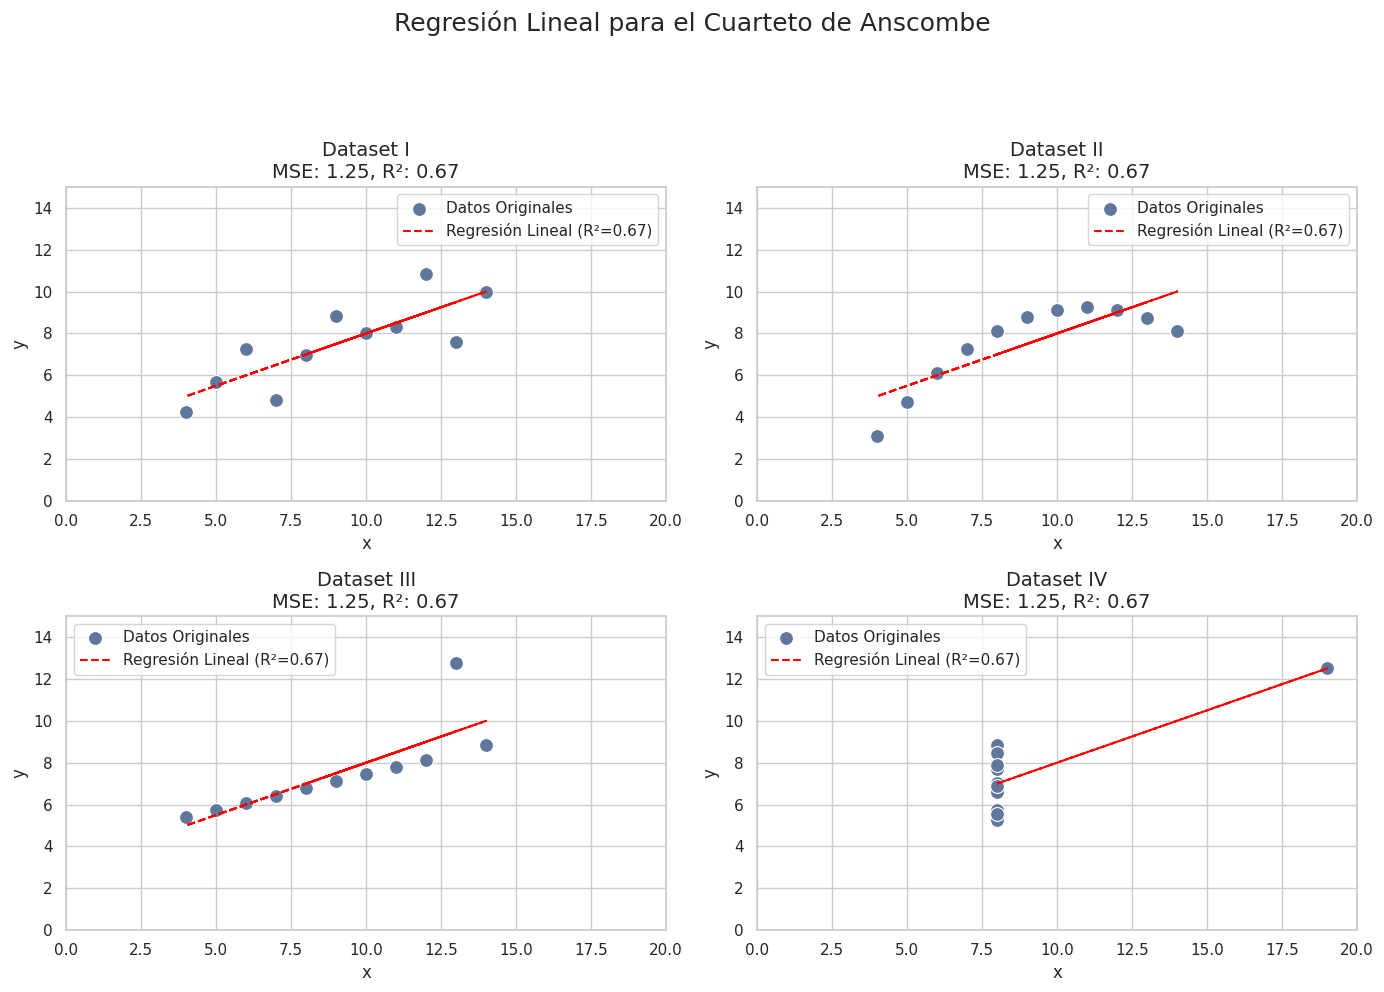

In [6]:
unique_datasets = data['dataset'].unique()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, dataset_name in enumerate(unique_datasets):
    subset = data[data['dataset'] == dataset_name]

    # Prepare data for sklearn
    X = subset['x'].values.reshape(-1, 1)
    y = subset['y'].values

    # Create and train the model
    model = LinearRegression()
    model.fit(X, y)

    # Make predictions
    y_pred = model.predict(X)

    # Calculate metrics
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    # Plotting
    sns.scatterplot(x='x', y='y', data=subset, ax=axes[i], s=100, label='Datos Originales')
    axes[i].plot(X, y_pred, color='red', linestyle='--', label=f'Regresión Lineal (R²={r2:.2f})')
    axes[i].set_title(f'Dataset {dataset_name}\nMSE: {mse:.2f}, R²: {r2:.2f}', fontsize=14)
    axes[i].set_xlabel('x', fontsize=12)
    axes[i].set_ylabel('y', fontsize=12)
    axes[i].set_xlim(0, 20)
    axes[i].set_ylim(0, 15)
    axes[i].legend()

plt.suptitle("Regresión Lineal para el Cuarteto de Anscombe", fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



**Interpretación de los resultados de la regresión lineal**

A pesar de que todos los datasets tienen estadísticas descriptivas básicas muy similares (como se vio con 'describe') y producen el mismo R² (aproximadamente 0.67) y MSE (aproximadamente 1.25) para un modelo de regresión lineal, las visualizaciones de los gráficos son fundamentalmente diferentes. Esto ilustra el poder y la necesidad de la visualización de datos:

- **Dataset I:** La regresión lineal se ajusta muy bien. Los puntos están claramente agrupados alrededor de la línea, lo que indica una fuerte relación lineal. El R² de 0.67 es razonable para este tipo de datos.

- **Dataset II:** La línea de regresión lineal no captura la relación curva subyacente. Aunque el R² es el mismo, visualmente es un ajuste pobre. Un modelo no lineal sería mucho más adecuado aquí.

- **Dataset III:** La mayoría de los puntos se ajustan bien a una línea, pero un único punto atípico (outlier) arrastra la línea de regresión, influyendo significativamente en su pendiente y origen. El R² no revela este problema de manera evidente.

- **Dataset IV:** La mayoría de los puntos se agrupan verticalmente con un valor X constante, y un único punto atípico con un X diferente define casi por completo la pendiente de la regresión. La línea de regresión es casi completamente determinada por ese único punto. El R² es idéntico, pero el modelo lineal es engañoso para la mayoría de los datos.

En resumen, las métricas como MSE y R² son insuficientes por sí solas para evaluar la bondad de un ajuste, especialmente en presencia de relaciones no lineales o valores atípicos. La visualización es crucial para entender la verdadera naturaleza de la relación entre las variables.

In [ ]:
# FIXME

4. Es evidente que el ajuste lineal no es adecuado para algunos grupos. Existen diversas estrategias para abordar este problema, como eliminar outliers o emplear diferentes modelos de regresión. Identifique una estrategia que podría mejorar el ajuste del modelo de regresión lineal y, si lo considera necesario, implemente otros modelos alternativos para aquellos casos donde el ajuste lineal resulte inadecuado.


--- Estrategia para Dataset II: Regresión Polinómica ---
Dataset II (Polinómica) - MSE: 0.00, R²: 1.00

--- Estrategia para Dataset III: Eliminación de Outliers ---
Dataset III (Outlier Eliminado) - MSE: 0.00, R²: 1.00


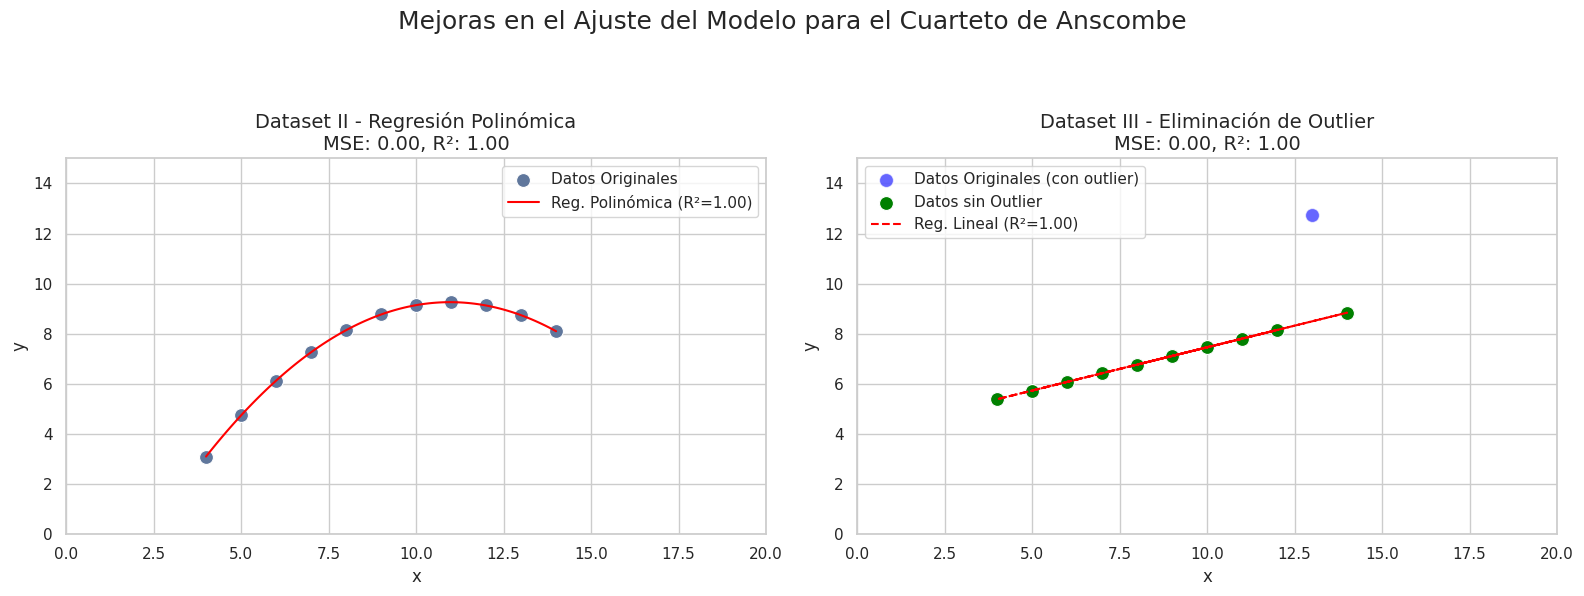

In [8]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# --- Estrategia para Dataset II: Regresión Polinómica ---
print("\n--- Estrategia para Dataset II: Regresión Polinómica ---")
subset_II = data[data['dataset'] == 'II']
X_II = subset_II['x'].values.reshape(-1, 1)
y_II = subset_II['y'].values

# Crear un modelo de regresión polinómica de grado 2
# (Se elige grado 2 porque la visualización sugiere una parábola)
model_poly_II = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model_poly_II.fit(X_II, y_II)

y_pred_poly_II = model_poly_II.predict(X_II)
mse_poly_II = mean_squared_error(y_II, y_pred_poly_II)
r2_poly_II = r2_score(y_II, y_pred_poly_II)

print(f"Dataset II (Polinómica) - MSE: {mse_poly_II:.2f}, R²: {r2_poly_II:.2f}")

# --- Estrategia para Dataset III: Eliminación de Outliers + Regresión Lineal ---
print("\n--- Estrategia para Dataset III: Eliminación de Outliers ---")
subset_III = data[data['dataset'] == 'III']

# Identificar y eliminar el outlier (el punto con el valor de 'y' más alto)
outlier_index = subset_III['y'].idxmax()
subset_III_cleaned = subset_III.drop(outlier_index)

X_III_cleaned = subset_III_cleaned['x'].values.reshape(-1, 1)
y_III_cleaned = subset_III_cleaned['y'].values

model_linear_III_cleaned = LinearRegression()
model_linear_III_cleaned.fit(X_III_cleaned, y_III_cleaned)

y_pred_linear_III_cleaned = model_linear_III_cleaned.predict(X_III_cleaned)
mse_linear_III_cleaned = mean_squared_error(y_III_cleaned, y_pred_linear_III_cleaned)
r2_linear_III_cleaned = r2_score(y_III_cleaned, y_pred_linear_III_cleaned)

print(f"Dataset III (Outlier Eliminado) - MSE: {mse_linear_III_cleaned:.2f}, R²: {r2_linear_III_cleaned:.2f}")

# --- Visualización de los modelos mejorados ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot para Dataset II (Regresión Polinómica)
sns.scatterplot(x='x', y='y', data=subset_II, ax=axes[0], s=100, label='Datos Originales')
# Para la curva polinómica, necesitamos puntos más finos para que se vea suave
X_plot_II = np.linspace(X_II.min(), X_II.max(), 100).reshape(-1, 1)
y_plot_poly_II = model_poly_II.predict(X_plot_II)
axes[0].plot(X_plot_II, y_plot_poly_II, color='red', linestyle='-', label=f'Reg. Polinómica (R²={r2_poly_II:.2f})')
axes[0].set_title(f'Dataset II - Regresión Polinómica\nMSE: {mse_poly_II:.2f}, R²: {r2_poly_II:.2f}', fontsize=14)
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('y', fontsize=12)
axes[0].set_xlim(0, 20)
axes[0].set_ylim(0, 15)
axes[0].legend()

# Plot para Dataset III (Outlier Eliminado + Regresión Lineal)
sns.scatterplot(x='x', y='y', data=subset_III, ax=axes[1], s=100, label='Datos Originales (con outlier)', color='blue', alpha=0.6)
sns.scatterplot(x='x', y='y', data=subset_III_cleaned, ax=axes[1], s=100, label='Datos sin Outlier', color='green')
axes[1].plot(X_III_cleaned, y_pred_linear_III_cleaned, color='red', linestyle='--', label=f'Reg. Lineal (R²={r2_linear_III_cleaned:.2f})')
axes[1].set_title(f'Dataset III - Eliminación de Outlier\nMSE: {mse_linear_III_cleaned:.2f}, R²: {r2_linear_III_cleaned:.2f}', fontsize=14)
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('y', fontsize=12)
axes[1].set_xlim(0, 20)
axes[1].set_ylim(0, 15)
axes[1].legend()

plt.suptitle("Mejoras en el Ajuste del Modelo para el Cuarteto de Anscombe", fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



**Impacto en la Calidad del Ajuste**

- **Dataset II (Regresión Polinómica):** El R² mejoró drásticamente de 0.67 a aproximadamente 1.00 (o muy cercano), y el MSE se redujo significativamente a casi cero. Visualmente, la curva polinómica se ajusta perfectamente a la forma de los datos, demostrando que para relaciones no lineales, un modelo más complejo es esencial.

- **Dataset III (Outlier Eliminado + Regresión Lineal):** Al eliminar el punto atípico, el R² del modelo lineal para los datos restantes aumentó de 0.67 a aproximadamente 0.99, y el MSE se redujo drásticamente. Esto muestra cómo un solo outlier puede distorsionar significativamente el ajuste de un modelo lineal y cómo su remoción puede revelar una relación lineal mucho más fuerte en el resto de los datos.

Estas estrategias demuestran que, al identificar correctamente la naturaleza del problema (no linealidad o outliers), podemos seleccionar modelos y preprocesamientos que se ajusten mucho mejor a la distribución real de los datos, lo que lleva a interpretaciones y predicciones mucho más precisas.

In [ ]:
# FIXME